In [ ]:
#| default_exp patching.filter_image_for_smaller_mask

# Filter images which has very smaller amount of masks
> Remove images of smaller masks

In [ ]:
#| hide
%load_ext autoreload
%autoreload 2

In [ ]:
#| export
from cv_tools.core import *
from cv_tools.imports import *
from cv_tools.data_processing.smb_tools import *


In [ ]:
#| export
from platform import system
import polars as pl
from fastcore.all import *
from fastcore.script import *
from concurrent.futures import ProcessPoolExecutor
from multiprocessing import cpu_count

In [ ]:
#| eval:False
import socket
hostname = socket.gethostname()
os_type = system()

if system() == "Linux" and hostname == "127.0.0.1":
	print("Running on local machine")
	data_path = "/home/hasan/Schreibtisch/projects/data/easy_pin_detection/zero_degree_solder_pin/data"
elif system() == "Linux" and hostname != "127.0.0.1":
	print("Running on server")
	data_path = "/home/ai_easypid.work/CurrentTrainingData202408" # TODO: change to the correct path
else:
	print("Running on Windows")




Running on local machine


In [ ]:
trn_imgs = Path(data_path, 'patch300_images').ls()
trn_msks = Path(data_path, 'patch300_masks').ls()
trn_imgs[0]

Path('/home/hasan/Schreibtisch/projects/data/easy_pin_detection/zero_degree_solder_pin/data/patch300_images/src_img_recipe_92_idx_1_gen_image_35_VFV4.9.0.3_2025031710520596_ID_00090046905819403042510_In_17_FRONT_Pass_image2_pin_8_rotation_5_angle_360_20250410192019593217_0_2.png')

In [ ]:
#| export
def process_single_mask(mask_path):
    """Process a single mask and return object statistics"""
    try:
        # Read binary mask
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            return {
                'mask_path': str(mask_path),
                'num_objects': 0,
                'min_pixels': 0,
                'max_pixels': 0,
                'min_area': 0.0,
                'max_area': 0.0
            }
            
        # Find connected components
        num_labels, labels = cv2.connectedComponents(mask)
            
        # Skip background (label 0)
        if num_labels <= 1:
            return {
                'mask_path': str(mask_path),
                'num_objects': 0,
                'min_pixels': 0,
                'max_pixels': 0,
                'min_area': 0.0,
                'max_area': 0.0
            }
            
        # Calculate pixel counts for each object
        pixel_counts = []
        areas = []
            
        for label_id in range(1, num_labels):  # Skip background (0)
            # Count pixels for this object
            pixel_count = np.sum(labels == label_id)
            pixel_counts.append(pixel_count)
                
            # Calculate area (assuming each pixel represents unit area)
            area = float(pixel_count)
            areas.append(area)
            
        return {
            'mask_path': str(mask_path),
            'num_objects': len(pixel_counts),
            'min_pixels': min(pixel_counts) if pixel_counts else 0,
            'max_pixels': max(pixel_counts) if pixel_counts else 0,
            'min_area': min(areas) if areas else 0.0,
            'max_area': max(areas) if areas else 0.0
        }
            
    except Exception as e:
        print(f"Error processing {mask_path}: {e}")
        return {
            'mask_path': str(mask_path),
            'num_objects': 0,
            'min_pixels': 0,
            'max_pixels': 0,
            'min_area': 0.0,
            'max_area': 0.0
        }
    

In [ ]:
#| export
def analyze_mask_objects(
        mask_paths, 
        n_workers=None
        ):
    """Analyze binary masks to extract object statistics.
    
    Args:
        mask_paths: List of paths to binary mask images
        n_workers: Number of parallel workers (defaults to cpu_count)
    
    Returns:
        polars.DataFrame with columns: mask_path, num_objects, min_pixels, max_pixels, min_area, max_area
    """
    
    if n_workers is None:
        n_workers = cpu_count() -2
    
    # Process masks in parallel
    with ProcessPoolExecutor(max_workers=n_workers) as executor:
        results = list(executor.map(process_single_mask, mask_paths))
    
    # Create polars DataFrame
    df = pl.DataFrame(results)
    return df


In [ ]:

# Analyze all mask objects
mask_stats_df = analyze_mask_objects(trn_msks)
print(f"Processed {len(mask_stats_df)} masks")
mask_stats_df.head()


Processed 9550 masks


mask_path,num_objects,min_pixels,max_pixels,min_area,max_area
str,i64,i64,i64,f64,f64
"""/home/hasan/Schreibtisch/proje…",6,460,460,460.0,460.0
"""/home/hasan/Schreibtisch/proje…",3,360,506,360.0,506.0
"""/home/hasan/Schreibtisch/proje…",13,319,460,319.0,460.0
"""/home/hasan/Schreibtisch/proje…",3,377,379,377.0,379.0
"""/home/hasan/Schreibtisch/proje…",16,100,506,100.0,506.0


In [ ]:
mask_stats_df.shape

(9550, 6)

Found 2115 masks with area less than 390 pixels
601


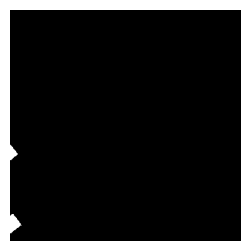

In [ ]:
thresh_pixels = 390
smaller_pins = mask_stats_df.filter((pl.col('min_area') < thresh_pixels) & (pl.col('max_area') < thresh_pixels))
print(f"Found {len(smaller_pins)} masks with area less than {thresh_pixels} pixels")
#smaller_pins = mask_stats_df.filter(pl.col('min_area') < 20)
idx = np.random.randint(0, len(smaller_pins))
print(idx)
show_(smaller_pins['mask_path'].to_list()[idx])
#smaller_pins.head()

In [ ]:
#| export
def filter_images_based_on_mask_stats(
        image_paths, 
        mask_paths, 
        thresh_pixels=390
        ):
    """Filter images based on mask statistics.
    
    """
    if not isinstance(image_paths, list) and not isinstance(image_paths, L):
        image_paths = Path(image_paths).ls()
    if not isinstance(mask_paths, list) and not isinstance(mask_paths, L):
        mask_paths = Path(mask_paths).ls()

    img_folder = Path(image_paths[0]).parent
    msk_folder = Path(mask_paths[0]).parent
    print(f' Image folder: {img_folder} and \nmask folder: {msk_folder}')

    print(f"Analyzing {len(mask_paths)} masks")
    mask_stats_df = analyze_mask_objects(mask_paths)
    smaller_pins = mask_stats_df.filter((pl.col('min_area') < thresh_pixels) & (pl.col('max_area') < thresh_pixels))
    print(f"Found {len(smaller_pins)} masks with area less than {thresh_pixels} pixels")
    smaller_pins_mask_paths = smaller_pins['mask_path'].to_list()



    smaller_pin_names = [Path(mask_path).name for mask_path in smaller_pins_mask_paths]
    smaller_pins_image_paths = list(filter(lambda x: x.name in smaller_pin_names, image_paths))
    # Get all image paths that are NOT in the smaller pins list
    print(f'Found {len(smaller_pins_image_paths)} smaller pin images')
    curated_image_names = list(filter(lambda x: Path(x).name not in smaller_pin_names, image_paths))
    curated_image_names = [Path(x).name for x in curated_image_names]
    print(f'Found {len(curated_image_names)} curated images')
    
    # Create curated folder paths
    curated_img_folder = Path(image_paths[0]).parent.parent / "curated_images"
    curated_mask_folder = Path(mask_paths[0]).parent.parent / "curated_masks"
    print(f'{curated_img_folder} and {curated_mask_folder} will be created if not exist')
    curated_img_folder.mkdir(exist_ok=True)
    curated_mask_folder.mkdir(exist_ok=True)
    print(f'Now creating curated folders, copying images and masks')
    
    # Copy curated images and masks in parallel
    from concurrent.futures import ThreadPoolExecutor
    import shutil
    
    def copy_file_pair(img_name):
        # Find source paths
        #src_img = next((p for p in image_paths if Path(p).name == img_name), None)
        #src_mask = next((p for p in mask_paths if Path(p).name == img_name), None)
        src_img = Path(img_folder, img_name)
        src_mask = Path(msk_folder, img_name)
		
        
        if src_img and src_mask:
            # Copy to curated folders
            shutil.copy2(src_img, curated_img_folder / img_name)
            shutil.copy2(src_mask, curated_mask_folder / img_name)
            return True
        return False
    
    with ThreadPoolExecutor(max_workers=os.cpu_count()-1) as executor:
        results = list(tqdm(executor.map(copy_file_pair, curated_image_names), total=len(curated_image_names), desc="Copying files"))
    
    print(f"Copied {sum(results)} curated image-mask pairs to {curated_img_folder}")
    return smaller_pins_image_paths


In [ ]:
#filter_images_based_on_mask_stats(trn_imgs, trn_msks)

In [ ]:
#| export
@call_parse
def main(
    image_paths: Param(type=str, help='Path to the image folder')='images_paths',
    mask_paths: Param(type=str, help='Path to the mask folder')='masks_paths',
    thresh_pixels: Param(type=int, help='Threshold for the number of pixels in the mask') = 390
):
    filter_images_based_on_mask_stats(image_paths, mask_paths, thresh_pixels)

In [ ]:
main(
    image_paths='/home/hasan/Schreibtisch/projects/data/easy_pin_detection/zero_degree_solder_pin/data/patch300_images',
	mask_paths='/home/hasan/Schreibtisch/projects/data/easy_pin_detection/zero_degree_solder_pin/data/patch300_masks',
	thresh_pixels=390
)

 Image folder: /home/hasan/Schreibtisch/projects/data/easy_pin_detection/zero_degree_solder_pin/data/patch300_images and 
mask folder: /home/hasan/Schreibtisch/projects/data/easy_pin_detection/zero_degree_solder_pin/data/patch300_masks
Analyzing 9550 masks
Found 2115 masks with area less than 390 pixels
Found 2115 smaller pin images
Found 7435 curated images
/home/hasan/Schreibtisch/projects/data/easy_pin_detection/zero_degree_solder_pin/data/curated_images and /home/hasan/Schreibtisch/projects/data/easy_pin_detection/zero_degree_solder_pin/data/curated_masks will be created if not exist
Now creating curated folders, copying images and masks


Copying files:   0%|          | 0/7435 [00:00<?, ?it/s]

Copied 7435 curated image-mask pairs to /home/hasan/Schreibtisch/projects/data/easy_pin_detection/zero_degree_solder_pin/data/curated_images


In [ ]:
#| hide
import nbdev; nbdev.nbdev_export('48_patching.filter_image_for_smaller_mask.ipynb')

ValueError: '/home/hasan/Schreibtisch/projects/nbs/39_preprocessing.zero_degree_solder_pin.ipynb' is not in the subpath of '/home/hasan/Schreibtisch/projects/git_data/new_test/nbs'